# ZOO Attack on MNIST-10

**Objective.** Craft adversarial examples for a 10-class MNIST digit classifier using **ZOO (Zeroth-Order Optimization)**, a *query-based, score-based black-box* attack that estimates the gradient from finite differences and then runs a C&W-style optimization on the estimate. Then train a binary detector that tries to catch those perturbations and see how well detection holds up as the attack strength changes.

## What you will do

1. Load the MNIST dataset and train a small CNN classifier from scratch (the target model). ZOO is only allowed to read its output probabilities.
2. Configure and run the ZOO attack with the Adversarial Robustness Toolbox (ART) to generate adversarial examples through query-based, gradient-free optimization.
3. Measure the damage: clean vs. adversarial accuracy, fooling rate, and perturbation size.
4. Visualize clean vs. adversarial digits side by side.
5. Generate a balanced clean/adversarial dataset and train a binary detector, then sweep the attack strength to test whether detection generalizes.

## Prerequisites

- Comfortable with CNNs, the black-box threat model (the attacker can only query the model's output, not its gradients or weights), and cross-entropy loss.
- Having built a white-box attack such as FGSM or PGD first (where the exact gradient is available) makes the contrast with ZOO's estimated gradient clearer, but is not required.

## Running this notebook

This is a self-contained notebook: it downloads MNIST, trains its own classifier, and generates its own adversarial examples, so no external model or dataset files are required. ZOO is far more query-expensive than FGSM or PGD, so this notebook runs it on a smaller slice of images with a capped iteration budget to keep runtimes reasonable. Generating adversarial examples is by far the slowest step; run the cells top to bottom and expect the attack cells to take a few minutes.

## Background: ZOO, a query-based black-box attack

Attacks like FGSM and PGD are *white-box*: they read the model's weights and backpropagate to get the exact gradient of the loss with respect to the input. **ZOO (Chen et al., 2017) has no such access.** It is a *black-box* attack (query access only) and *query-based* (cost is counted in **queries**, not gradient computations), and it asks a simple question: if the only thing missing is the gradient, why not *estimate* it from queries and then run a white-box-style optimizer on the estimate?

"Zeroth-order" means optimizing using only function values, with no analytic derivatives. ZOO estimates each partial derivative with a **symmetric finite difference**:

$$\frac{\partial L}{\partial x_i} \approx \frac{L(x + h\,e_i) - L(x - h\,e_i)}{2h},$$

where $e_i$ is the unit vector along input coordinate $i$ and $h$ is a small step. It assembles these coordinate-wise estimates into an approximate gradient and feeds it into a **C&W-style optimization**, a margin-based objective, now driven by estimated rather than exact gradients.

The trade-off defines the attack. Each coordinate costs two queries per gradient estimate, so one approximate gradient over a $d$-dimensional image costs on the order of $2d$ queries, and the optimizer needs many gradients across its iterations. ZOO is therefore **accurate** (often rivaling white-box success) but **query-expensive**, which is why this notebook runs it on a small slice of images with a capped iteration budget. It is **score-based** throughout: the loss it differences is computed from the model's output probabilities, not from a hard top-1 label.

This contrasts with simpler black-box attacks (e.g. SimBA) that skip gradient estimation entirely and greedily search for a perturbation that lowers the true-class probability. Those attacks spend few queries; ZOO spends many to recover something closer to white-box precision.

## 1. Setup

Install the one external dependency, the Adversarial Robustness Toolbox (ART), then import everything the notebook uses. TensorFlow/Keras, NumPy, and Matplotlib are already available on Colab and in most local ML environments; ART is not, so we install it here.

In [1]:
# ART (Adversarial Robustness Toolbox) provides the ZOO attack and the BinaryInputDetector.
# TensorFlow/Keras, NumPy, and Matplotlib are usually pre-installed (e.g. on Colab);
# uncomment the second line if your environment is missing them.
!pip install adversarial-robustness-toolbox
# !pip install tensorflow numpy matplotlib

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 10.7 MB/s eta 0:00:00


In [2]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import tensorflow as tf
from matplotlib import pyplot as plt

# ART components used in this notebook:
# - KerasClassifier wraps a Keras model in ART's estimator interface.
# - ZooAttack is the query-based, score-based black-box evasion attack.
# - BinaryInputDetector wraps a binary CNN as an adversarial-input detector.
from art.estimators.classification import KerasClassifier
from art.attacks.evasion import ZooAttack
from art.defences.detector.evasion import BinaryInputDetector

## 2. Load and prepare the data

MNIST is 28x28 grayscale images of handwritten digits (0-9). We normalize pixels to `[0, 1]`, add a trailing channel axis for the CNN, and one-hot encode the labels. **The `[0, 1]` scale matters for ZOO too:** the classifier's `clip_values` and ZOO's finite-difference step are both expressed on this scale, so the data range and the attack settings must agree.

ZOO is far more expensive than FGSM or PGD: each gradient estimate costs on the order of $2 \times 784$ queries for a single $28\times28$ image. To keep the live attack tractable, we work with a small slice of 50 test images instead of the 500 used for white-box attacks.

In [3]:
# Load MNIST and normalize pixel values from [0, 255] to [0, 1].
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.mnist.load_data()
x_train = x_train.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0

# Add a channel axis: (N, 28, 28) -> (N, 28, 28, 1).
x_train = np.expand_dims(x_train, axis=-1)
x_test = np.expand_dims(x_test, axis=-1)

# One-hot encode labels for the 10 digit classes.
nb_classes = 10
y_train = tf.keras.utils.to_categorical(y_train, num_classes=nb_classes)
y_test = tf.keras.utils.to_categorical(y_test, num_classes=nb_classes)

# ZOO is query-expensive, so we work with a small slice of 50 test images.
x_test = x_test[:50]
y_test = y_test[:50]

print("x_train:", x_train.shape, "x_test:", x_test.shape, "pixel range:", (float(x_test.min()), float(x_test.max())))

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
x_train: (60000, 28, 28, 1) x_test: (50, 28, 28, 1) pixel range: (0.0, 1.0)


### A quick look at the clean data

Before training or attacking anything, sanity-check the inputs: one clean example per digit class, shown in grayscale. If these look wrong, every downstream figure will be unreliable.

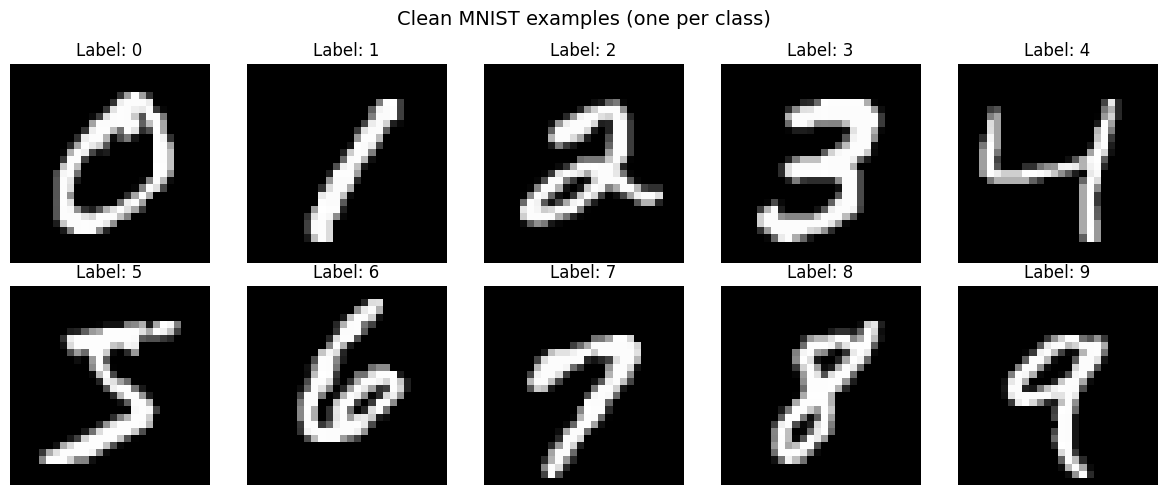

In [4]:
# Show one clean example per digit (0-9) in grayscale.
train_labels = np.argmax(y_train, axis=1)
fig, axes = plt.subplots(2, 5, figsize=(12, 5))
for i, ax in enumerate(axes.flatten()):
    idx = np.where(train_labels == i)[0][0]
    ax.imshow(x_train[idx].squeeze(), cmap='gray')
    ax.set_title(f"Label: {i}", fontsize=12)
    ax.axis('off')
fig.suptitle("Clean MNIST examples (one per class)", fontsize=14)
plt.tight_layout()
plt.show()

## 3. Build and train the target model

The target is a small CNN: three convolution+pooling blocks feeding into two dense layers (a 128-unit hidden layer and a 10-way softmax output). We train it from scratch on clean MNIST with no adversarial defenses, so any accuracy drop under attack can be attributed to the attack rather than to weak or defended training.

We reuse this same architecture later for the clean-vs-adversarial detector, just with a 2-class output instead of 10. In the black-box threat model, ZOO is only allowed to call this model as a **query oracle**: it reads output probabilities and never touches the weights or gradients directly.

In [5]:
def build_cnn_classifier(num_classes):
    """3 conv blocks + 2 dense layers. Used for both the target classifier
    (num_classes=10) and the clean-vs-adversarial detector (num_classes=2)."""
    return tf.keras.models.Sequential([
        tf.keras.layers.Conv2D(32, (3, 3), activation='relu', input_shape=(28, 28, 1)),
        tf.keras.layers.MaxPooling2D((2, 2)),
        tf.keras.layers.Conv2D(64, (3, 3), activation='relu'),
        tf.keras.layers.MaxPooling2D((2, 2)),
        tf.keras.layers.Conv2D(128, (3, 3), activation='relu'),
        tf.keras.layers.MaxPooling2D((2, 2)),
        tf.keras.layers.Flatten(),
        tf.keras.layers.Dense(128, activation='relu'),
        tf.keras.layers.Dropout(0.2),
        tf.keras.layers.Dense(num_classes, activation='softmax'),
    ])


In [6]:
model = build_cnn_classifier(nb_classes)
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 3, 3, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 1, 1, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 110,474 (431.54 KB)

 Trainable params: 110,474 (431.54 KB)

 Non-trainable params: 0 (0.00 B)

In [7]:
# Train the target classifier on clean MNIST. A handful of epochs is enough
# for this architecture to reach roughly 99% clean test accuracy.
model.fit(x_train, y_train, epochs=5, batch_size=128, validation_split=0.1, verbose=1)

Epoch 1/5
422/422 ━━━━━━━━━━━━━━━━━━━━ 49s 105ms/step - accuracy: 0.8942 - loss: 0.3496 - val_accuracy: 0.9728 - val_loss: 0.0905
Epoch 2/5
422/422 ━━━━━━━━━━━━━━━━━━━━ 79s 99ms/step - accuracy: 0.9683 - loss: 0.1059 - val_accuracy: 0.9763 - val_loss: 0.0784
Epoch 3/5
422/422 ━━━━━━━━━━━━━━━━━━━━ 42s 98ms/step - accuracy: 0.9766 - loss: 0.0772 - val_accuracy: 0.9835 - val_loss: 0.0548
Epoch 4/5
422/422 ━━━━━━━━━━━━━━━━━━━━ 83s 100ms/step - accuracy: 0.9809 - loss: 0.0602 - val_accuracy: 0.9852 - val_loss: 0.0507
Epoch 5/5
422/422 ━━━━━━━━━━━━━━━━━━━━ 41s 97ms/step - accuracy: 0.9845 - loss: 0.0491 - val_accuracy: 0.9870 - val_loss: 0.0434


## 4. Configure and run the ZOO attack

### Wrap the model for ART

ART attacks operate on an *estimator*, not a raw Keras model. We wrap the classifier with `KerasClassifier` and declare the valid pixel range via `clip_values=(0.0, 1.0)`. ZOO queries this wrapped classifier's output probabilities to form its finite-difference gradient estimates, and clips each adversarial example back into `[0, 1]`.

In [8]:
# Wrap the target model in ART's estimator interface.
# clip_values must match the normalized pixel range [0.0, 1.0].
# ZOO only queries this classifier's output probabilities; it never accesses gradients or weights.
classifier = KerasClassifier(model=model, clip_values=(0.0, 1.0), use_logits=False)

### Build the attack

ZOO's behavior is set by a few parameters:

| Parameter | Role |
|-----------|------|
| `learning_rate` | Step size of the coordinate updates in the C&W-style optimization. This is the "attack strength" we sweep in Section 7. |
| `max_iter` | Number of optimization iterations; each iteration spends finite-difference queries, so this drives the query cost. We cap it at 100 (a research-grade run might use 500+) to keep this notebook tractable. |
| `nb_parallel` | Number of coordinates whose gradients are estimated in parallel per step. |
| `batch_size` | Number of images processed together. |
| `targeted` | `False`: we only need the model to be wrong, not wrong in a specific chosen class. |

Because each estimated coordinate costs a pair of queries, ZOO's query count grows with both `max_iter` and the image dimensionality, which is exactly why we run it here on a small slice of MNIST images with a modest iteration budget.

In [9]:
attack_zoo = ZooAttack(
    classifier=classifier,
    learning_rate=1.0,
    targeted=False,
    max_iter=100,
    verbose=True,
    batch_size=32,
    nb_parallel=32,
)

### Generate adversarial examples

We run ZOO on the 50 held-out test images to produce `x_test_adv`. This is the slowest cell in the notebook: each image needs many finite-difference gradient estimates, so expect it to take a few minutes.

In [10]:
# Generate ZOO adversarial examples for the 50 test images (learning_rate = 1.0).
x_test_adv = attack_zoo.generate(x=x_test)

print("x_test_adv:", x_test_adv.shape, "y_test:", y_test.shape)

ZOO:   0%|          | 0/2 [00:00<?, ?it/s]

x_test_adv: (50, 28, 28, 1) y_test: (50, 10)


## 5. Evaluate the attack

Read the black-box result the same way as a white-box one, but remember ZOO reconstructed its gradient purely from queries:

- **Accuracy drop.** Clean accuracy (near 99%) vs. adversarial accuracy. The gap is the **fooling rate**.
- **Perturbation size.** The mean absolute per-pixel change needed to flip the prediction. Unlike FGSM/PGD, ZOO has no fixed `eps` budget: its C&W-style objective minimizes the perturbation it needs, so there is no epsilon to compare it against.

> **Query cost.** ZOO's accuracy comes at a price: many finite-difference gradients, each on the order of $2d$ queries. On a public API, that query volume is exactly what rate limiting and monitoring are designed to catch.

In [11]:
# Clean accuracy on the 50 clean test images.
_, clean_acc = model.evaluate(x_test, y_test, verbose=0)

# Adversarial accuracy on the ZOO examples.
_, adv_acc = model.evaluate(x_test_adv, y_test, verbose=0)

# Perturbation size between clean and adversarial images.
mean_abs = np.mean(np.abs(x_test_adv - x_test))

print(f"Clean accuracy:        {clean_acc * 100:5.2f}%")
print(f"Adversarial accuracy:  {adv_acc * 100:5.2f}%")
print(f"Fooling rate:          {(clean_acc - adv_acc) * 100:5.2f} percentage points")
print(f"Mean |perturbation|:   {mean_abs:.4f}  (per pixel, on the [0, 1] scale)")

Clean accuracy:        96.00%
Adversarial accuracy:  94.00%
Fooling rate:           2.00 percentage points
Mean |perturbation|:   0.0056  (per pixel, on the [0, 1] scale)


## 6. Visualize clean vs. adversarial examples

The top row shows clean digits with the model's prediction; the bottom row shows the ZOO version of the same digit with the model's (now often wrong) prediction. The two rows look nearly identical, yet many predictions flip. Green titles mark correct predictions, red marks the misclassifications the attack caused.

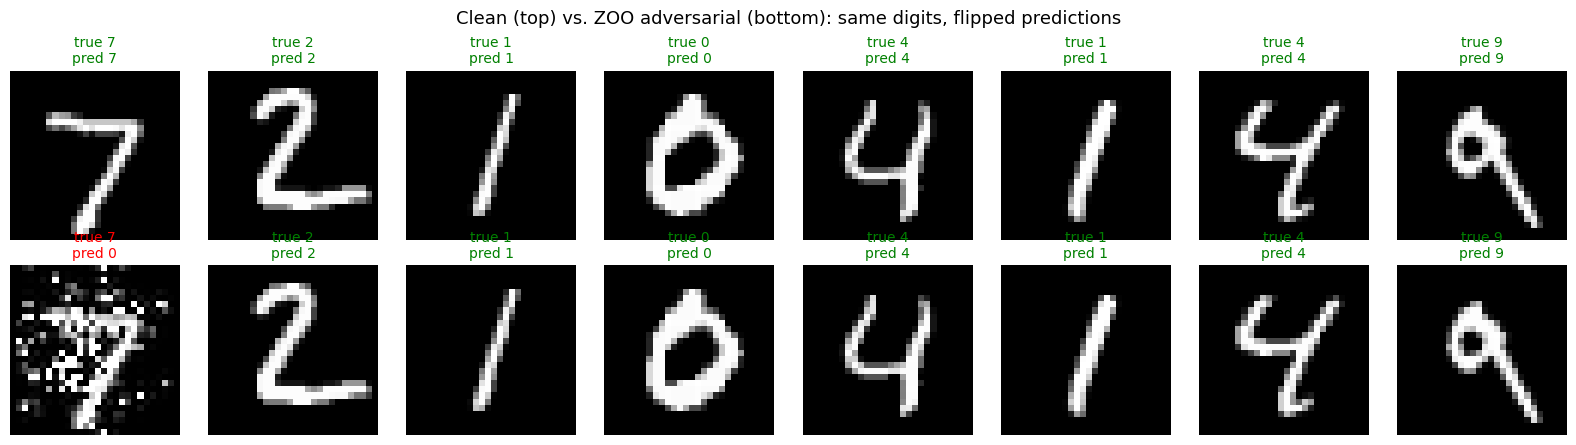

In [12]:
# Compare clean and adversarial versions of the same images side by side.
n = 8
clean_preds = np.argmax(model.predict(x_test[:n], verbose=0), axis=1)
adv_preds = np.argmax(model.predict(x_test_adv[:n], verbose=0), axis=1)
true_labels = np.argmax(y_test[:n], axis=1)

fig, axes = plt.subplots(2, n, figsize=(2 * n, 4.5))
for j in range(n):
    # Top row: clean image.
    axes[0, j].imshow(x_test[j].squeeze(), cmap='gray')
    color = 'green' if clean_preds[j] == true_labels[j] else 'red'
    axes[0, j].set_title(f"true {true_labels[j]}\npred {clean_preds[j]}", fontsize=10, color=color)
    axes[0, j].axis('off')

    # Bottom row: adversarial image.
    axes[1, j].imshow(x_test_adv[j].squeeze(), cmap='gray')
    color = 'green' if adv_preds[j] == true_labels[j] else 'red'
    axes[1, j].set_title(f"true {true_labels[j]}\npred {adv_preds[j]}", fontsize=10, color=color)
    axes[1, j].axis('off')

fig.suptitle("Clean (top) vs. ZOO adversarial (bottom): same digits, flipped predictions", fontsize=13)
plt.tight_layout()
plt.show()

## 7. Adversarial-example detector

We now switch sides and build a defense: a binary CNN that classifies each input as **clean** or **adversarial**. It is trained on a balanced mix of clean images and their ZOO counterparts. The idea is that ZOO's optimization leaves a signature in feature space that a CNN can learn to spot, even though the perturbation is invisible to us.

### Generate the detector training data

We take 50 clean training images (disjoint from the test set used above) and attack them with the same ZOO attack at `learning_rate = 1.0` to get 50 adversarial counterparts. Stacking the two gives a balanced set of 100 samples with binary labels: `[1, 0]` = clean, `[0, 1]` = adversarial. We keep this set small because each image costs many ZOO queries to attack; the assignment below asks you to scale it up.

In [13]:
# 50 clean training images and their ZOO-adversarial counterparts (learning_rate = 1.0).
x_train_clean_detector = x_train[:50]
x_train_adv_detector = attack_zoo.generate(x=x_train_clean_detector)

x_train_detector = np.concatenate([x_train_clean_detector, x_train_adv_detector], axis=0)
y_train_detector = np.concatenate([
    np.tile([1, 0], (50, 1)),   # clean
    np.tile([0, 1], (50, 1)),   # adversarial
], axis=0).astype("float32")

# Shuffle so clean/adversarial examples are interleaved during training.
shuffle_idx = np.random.permutation(len(x_train_detector))
x_train_detector = x_train_detector[shuffle_idx]
y_train_detector = y_train_detector[shuffle_idx]

print("x_train_detector:", x_train_detector.shape, "y_train_detector:", y_train_detector.shape)

ZOO:   0%|          | 0/2 [00:00<?, ?it/s]

x_train_detector: (100, 28, 28, 1) y_train_detector: (100, 2)


### Build and train the detector

The detector reuses the same `build_cnn_classifier` architecture as the target model (3 conv blocks + 2 dense layers), just with a 2-class softmax head (clean vs. adversarial) instead of 10. A small dataset like this one needs more epochs to converge than the larger sets used for FGSM/PGD detectors.

In [14]:
# Binary CNN detector: same architecture as the classifier, with a 2-class output head.
detector_model = build_cnn_classifier(2)
detector_model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

detector_model.fit(x_train_detector, y_train_detector, epochs=20, batch_size=16, verbose=1)

Epoch 1/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 2s 17ms/step - accuracy: 0.4000 - loss: 0.7052
Epoch 2/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.5300 - loss: 0.6924
Epoch 3/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.4900 - loss: 0.6985
Epoch 4/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.4600 - loss: 0.6991
Epoch 5/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.4200 - loss: 0.6980
Epoch 6/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.4900 - loss: 0.6938
Epoch 7/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.4900 - loss: 0.6938
Epoch 8/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.5000 - loss: 0.6927
Epoch 9/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.4700 - loss: 0.6958
Epoch 10/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.5000 - loss: 0.6935
Epoch 11/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.4700 - loss: 0.6951
Epoch 12/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.5300 - loss: 0.6909
E

### Wrap the detector with ART's BinaryInputDetector

`BinaryInputDetector` gives the detector the same ART interface as the attack, so `detect(x)` returns a per-sample adversarial flag. We wrap the trained Keras model with `KerasClassifier` (again with `clip_values=(0.0, 1.0)`) and hand it to the detector.

In [15]:
# Wrap the trained detector as an ART estimator, then in a BinaryInputDetector.
detector_classifier = KerasClassifier(model=detector_model, clip_values=(0.0, 1.0), use_logits=False)
detector = BinaryInputDetector(detector_classifier)

# Fit the detector within ART's interface on the balanced training set.
detector.fit(x_train_detector, y_train_detector, nb_epochs=3, batch_size=16)

### How well does the detector catch the attack?

We check both sides of the trade-off: how many of the 50 test-set adversarial images it flags (true positives), and how many of the 50 clean test images it wrongly flags (false positives).

In [16]:
# Flagged adversarial examples (true positives).
_, flags_adv = detector.detect(x_test_adv)
n_flag_adv = int(np.sum(flags_adv))

# Flagged clean examples (false positives).
_, flags_clean = detector.detect(x_test)
n_flag_clean = int(np.sum(flags_clean))

print(f"Adversarial images flagged: {n_flag_adv} / {len(x_test_adv)}  (higher is better)")
print(f"Clean images flagged:       {n_flag_clean} / {len(x_test)}  (lower is better)")

Adversarial images flagged: 50 / 50  (higher is better)
Clean images flagged:       50 / 50  (lower is better)


### Does the detector generalize across attack strengths?

The detector was trained only on `learning_rate = 1.0` examples. Now we sweep the ZOO learning rate across weaker values, regenerating adversarial examples at each strength (with a small `max_iter` and a smaller probe set to keep this tractable), and count two things per 20 images:

- how many the **detector flags** as adversarial, and
- how many actually **fool the classifier**.

If detection were a general defense, the flagged curve would track the fooled curve everywhere. Note that every swept value here is *weaker* than the `learning_rate = 1.0` the detector was trained on.

> This cell runs ZOO live at each learning rate, so it is one of the slowest steps in the notebook. Shorten `learning_rates` or reduce `n_samples` to speed it up.

In [17]:
# The detector was trained at learning_rate = 1.0; sweep weaker ZOO learning rates to test generalization.
learning_rates = [0.01, 0.02, 0.03, 0.05, 0.1, 0.2, 0.3]
n_samples = 20
x_probe = x_test[:n_samples]
y_probe = np.argmax(y_test[:n_samples], axis=1)

n_flagged = []   # detector flags per n_samples
n_fooled = []    # classifier errors per n_samples

# Use a small, fixed iteration budget so the live sweep stays fast.
attack_zoo.set_params(max_iter=10)

for rate in learning_rates:
    attack_zoo.set_params(learning_rate=rate)
    x_adv = attack_zoo.generate(x=x_probe)
    n_flagged.append(int(np.sum(detector.detect(x_adv)[1])))
    preds = np.argmax(classifier.predict(x_adv), axis=1)
    n_fooled.append(int(np.sum(preds != y_probe)))

# Prepend the clean (learning_rate = 0) baseline for reference.
clean_preds = np.argmax(classifier.predict(x_probe), axis=1)
lr_axis = [0.0] + learning_rates
n_flagged = [n_flag_clean] + n_flagged
n_fooled = [int(np.sum(clean_preds != y_probe))] + n_fooled

ZOO:   0%|          | 0/1 [00:00<?, ?it/s]

ZOO:   0%|          | 0/1 [00:00<?, ?it/s]

ZOO:   0%|          | 0/1 [00:00<?, ?it/s]

ZOO:   0%|          | 0/1 [00:00<?, ?it/s]

ZOO:   0%|          | 0/1 [00:00<?, ?it/s]

ZOO:   0%|          | 0/1 [00:00<?, ?it/s]

ZOO:   0%|          | 0/1 [00:00<?, ?it/s]

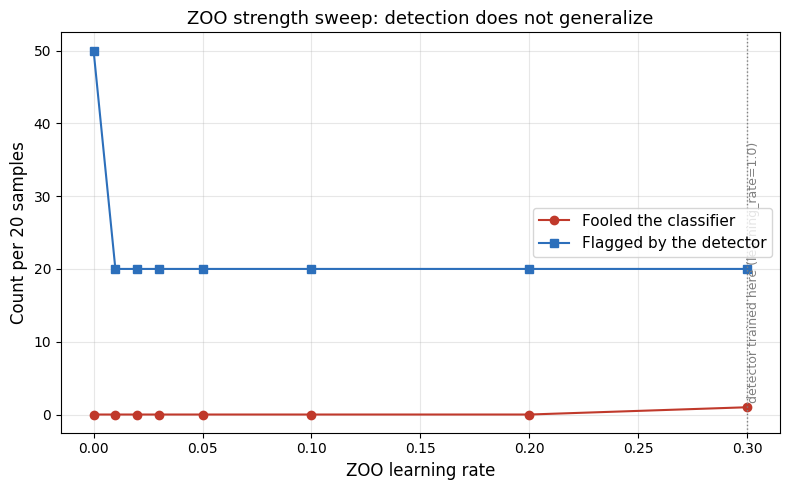

In [19]:
# Plot detector flags against classifier fooling as attack strength varies.
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(lr_axis, n_fooled, marker='o', color='#c0392b', label='Fooled the classifier')
ax.plot(lr_axis, n_flagged, marker='s', color='#2c6fbb', label='Flagged by the detector')

# Mark the single strength the detector was trained on.
ax.axvline(0.3, color='gray', linestyle=':', linewidth=1)
ax.text(0.3, ax.get_ylim()[1] * 0.02, ' detector trained here (learning_rate=1.0)',
        rotation=90, va='bottom', ha='left', fontsize=9, color='gray')

ax.set_xlabel('ZOO learning rate', fontsize=12)
ax.set_ylabel(f'Count per {n_samples} samples', fontsize=12)
ax.set_title('ZOO strength sweep: detection does not generalize', fontsize=13)
ax.grid(True, alpha=0.3)
ax.legend(loc='center right', fontsize=11)
plt.tight_layout()
plt.show()

> **Takeaway.** The detector is reliable only near the strength it was trained on (`learning_rate = 1.0`). Across the weaker range swept above, the flagged and fooled curves need not agree: weak ZOO settings can leave a signature the detector was not trained to see, or fool the classifier without tripping it. A detector calibrated at one strength does **not** generalize across the spectrum. Detection is an *empirical* defense: it works against the attacks you trained it on and offers no guarantee against the ones you did not.

## Key takeaways

- **ZOO recovers white-box precision from queries alone.** By estimating each partial derivative with a symmetric finite difference and optimizing a C&W-style objective, ZOO fools the model without ever seeing its gradients, the black-box counterpart to white-box attacks like FGSM and PGD.
- **Accuracy is bought with queries.** Each gradient estimate costs on the order of $2d$ queries, so ZOO is powerful but query-expensive; on a real API that query volume is exactly what rate limiting and anomaly detection are designed to catch.
- **Score-based attacks depend on the probability signal.** ZOO differences the loss computed from output probabilities, so returning only a coarse top-1 label removes the signal it relies on.
- **Detection is empirical, not guaranteed.** A binary detector trained at one ZOO learning rate does not generalize across the strength spectrum, so it must be paired with query-side defenses (rate limiting, anomaly detection) rather than trusted on its own.

## Assignment

Complete each item directly in this notebook, re-running from that point forward.

1. Why does the detector only need 2 outputs while the target classifier needs 10?
2. Why would an attacker choose ZOO over a white-box attack like PGD, given its far higher query cost?
3. Add or remove one convolutional block in `build_cnn_classifier`, retrain, and report whether clean and adversarial accuracy at `learning_rate = 1.0` rose or fell.
4. Grow the detector's training set from 50 clean + 50 adversarial to 100 + 100, retrain, and report whether detection performance changed.
5. Set `learning_rate = 0.1`, re-run the attack, and report the new clean/adversarial accuracy and perturbation size.
6. **(General knowledge.)** What non-technical (business or policy) measures could a public ML API use to make query-based attacks like ZOO harder or more expensive?

You have completed this lab when you have answered 1, 2, and 6, and reported your findings for 3-5.